# Acute Respiratory Infection Analysis - France

Analysis of incidence rates from 2020-2026 using Sentinelles network data.
source: https://www.sentiweb.fr/france/en/?page=table&maladie=25

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [33]:
df = pd.read_csv('inc-25-PAY-ds2.csv')
df.shape
df.head()
df.describe()

,"query:{""geo_ref"":""insee""",indicator:25.1,"type:""all""",period:[202016,202606],"geo:[""PAY""",1]},compact:false,"time:""week"".1","source:""r&#233;seau Sentinelles",INSERM,Sorbonne Universit&#233;,"https://www.sentiweb.fr""","date:""2026-02-11T16:32:09+0100""}"
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
#remove annoying header row and drop any rows with missing values
df = pd.read_csv('inc-25-PAY-ds2.csv', skiprows=1)
df.dropna(inplace=True)
df.shape
df.head()
df.describe()

,week,indicator,inc,inc100,inc_up,inc_low,inc100_up,inc100_low
count,304.000000,304.0,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,202295.467105,25.0,100418.625000,150.825658,104495.039474,96342.210526,156.927632,144.713816
std,169.164065,0.0,81684.226082,122.353728,83224.266927,80148.278974,124.681170,120.066952
min,202016.000000,25.0,8978.000000,14.000000,10179.000000,7777.000000,15.000000,12.000000
25%,202138.750000,25.0,45153.000000,68.000000,48364.000000,42078.750000,72.000000,62.750000
50%,202310.500000,25.0,72660.500000,109.500000,76109.000000,69212.000000,114.500000,104.500000
75%,202434.250000,25.0,126370.000000,188.500000,131704.500000,120934.750000,196.500000,180.500000
max,202606.000000,25.0,477721.000000,720.000000,486801.000000,468641.000000,734.000000,707.000000


In [35]:
df['year'] = df['week'] // 100
df['week_num'] = df['week'] % 100
df['date'] = pd.to_datetime(df['year'].astype(str) + '-W' + df['week_num'].astype(str).str.zfill(2) + '-1', 
                           format='%Y-W%W-%w') #from chatGPT


Let's plot the incidence rate by date, always a good idea!

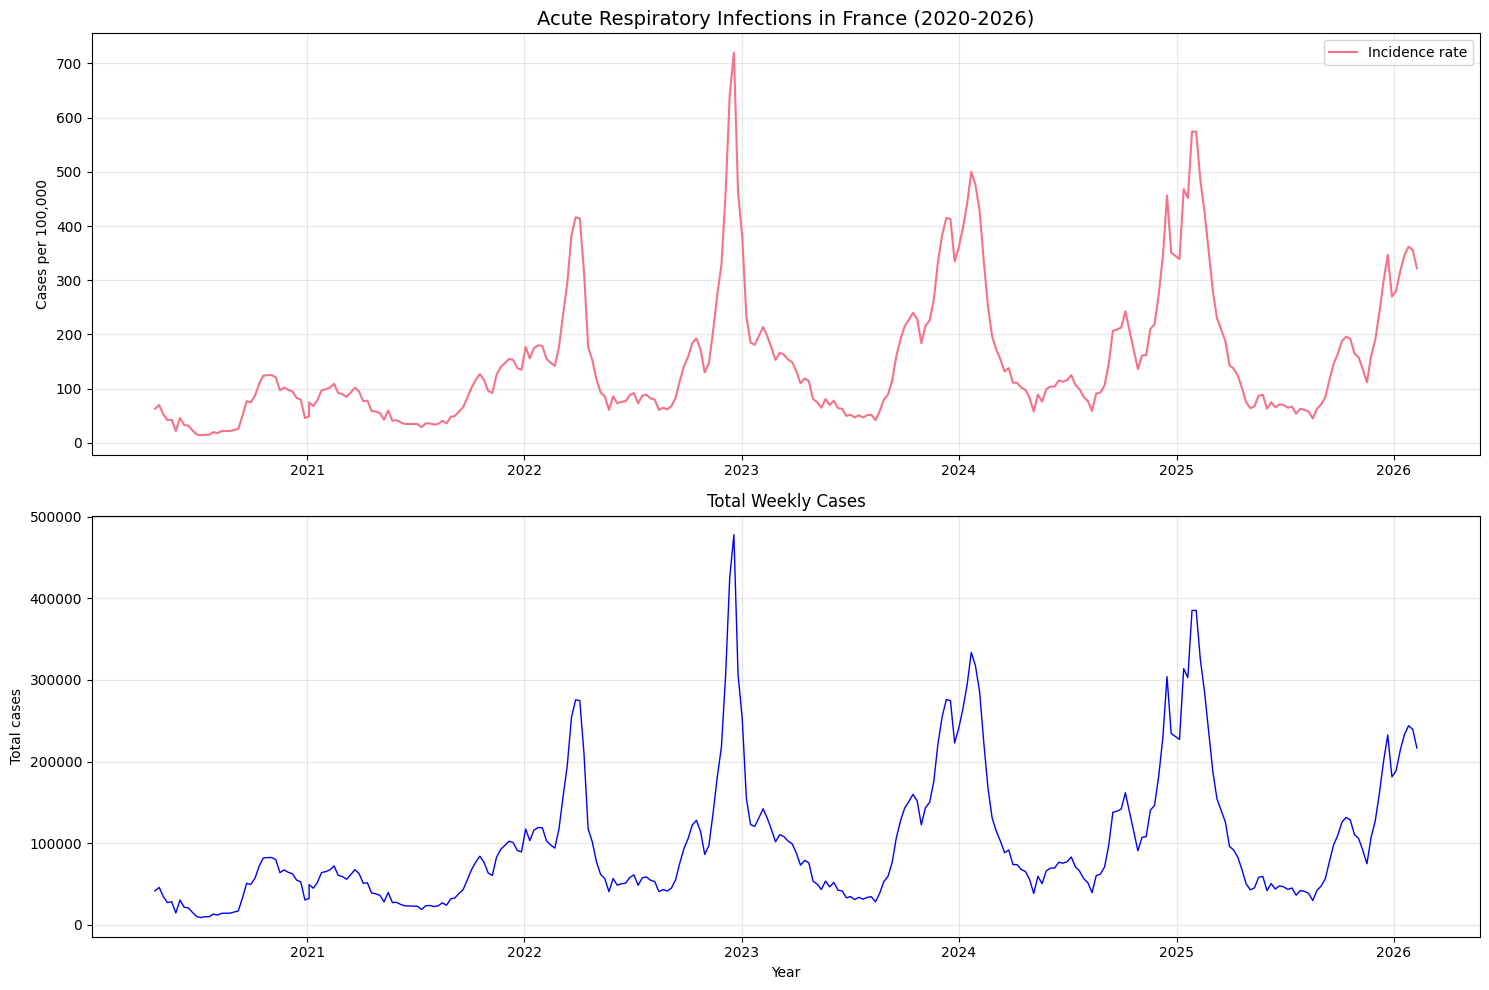

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.plot(df['date'], df['inc100'], label='Incidence rate')
ax1.set_ylabel('Cases per 100,000')
ax1.set_title('Acute Respiratory Infections in France (2020-2026)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(df['date'], df['inc'], color='blue', linewidth=1)
ax2.set_ylabel('Total cases')
ax2.set_xlabel('Year')
ax2.set_title('Total Weekly Cases', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

There seems to be a seasonal pattern, let's explore this further.

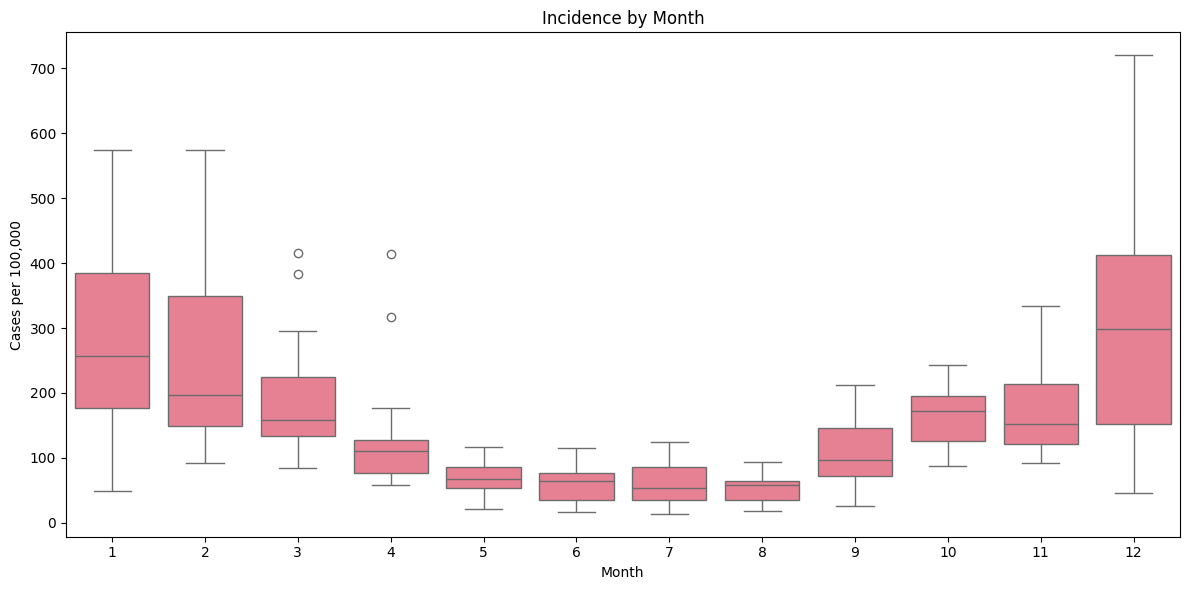

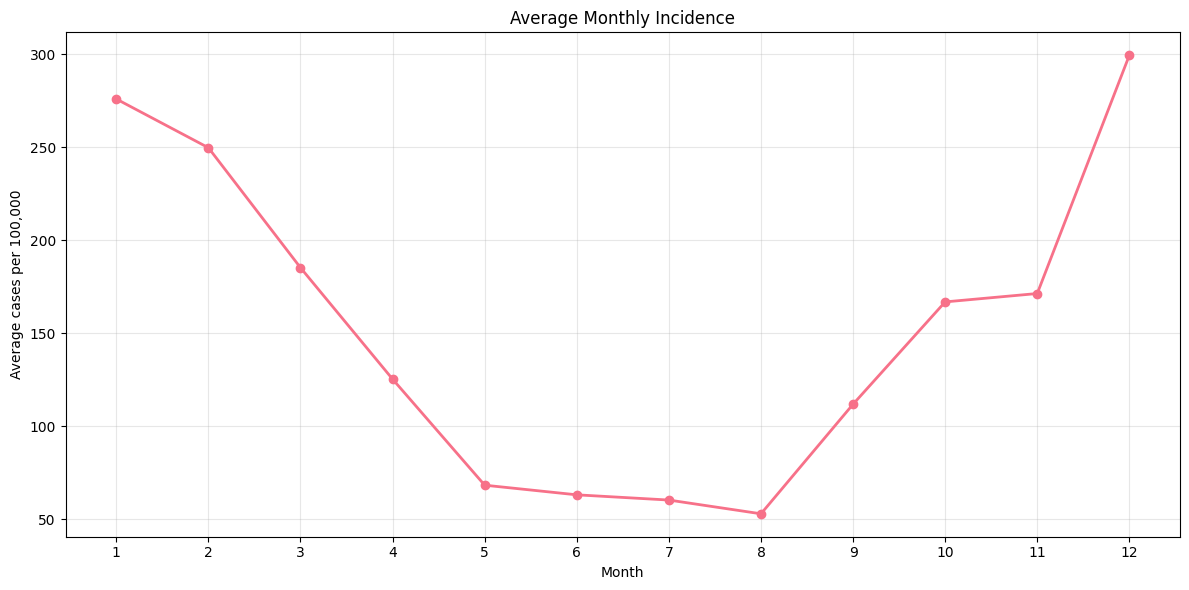

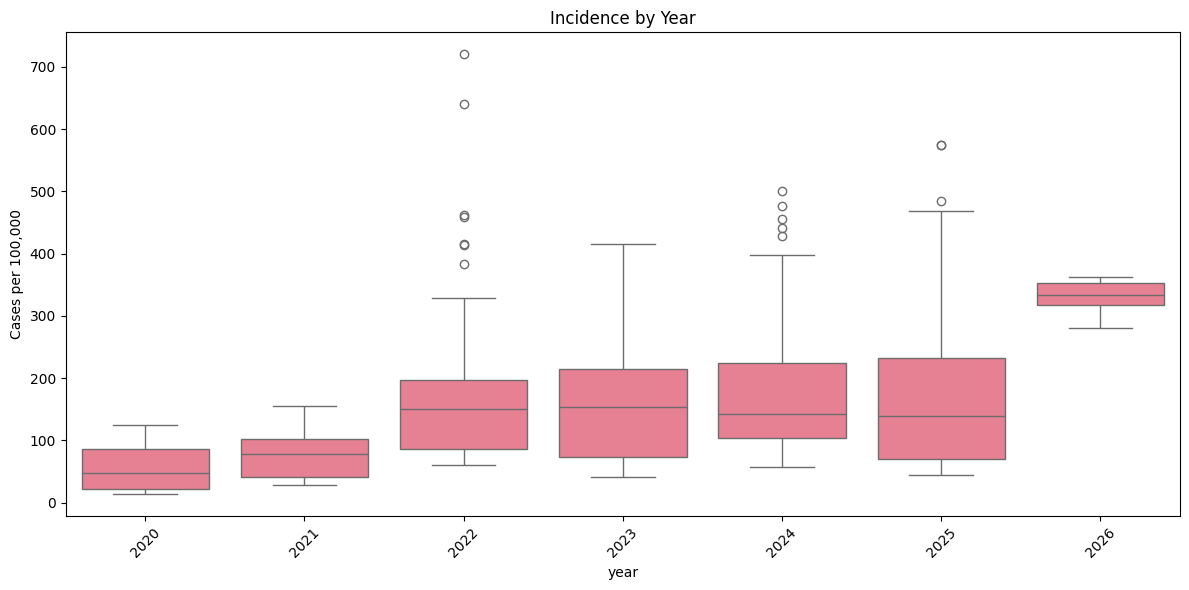

In [39]:
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['inc100'].mean()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='month', y='inc100')
plt.title('Incidence by Month')
plt.ylabel('Cases per 100,000')
plt.xlabel('Month')
plt.xticks(range(12))
plt.tight_layout()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
plt.title('Average Monthly Incidence')
plt.xlabel('Month')
plt.ylabel('Average cases per 100,000')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='inc100')
plt.title('Incidence by Year')
plt.ylabel('Cases per 100,000')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Conclusion

- Seasonal cycle which peaks at winters
- There seems to be a big jump between 2021 and 2022, maybe due to COVID-19 measures being lifted